
**DQN with PyTorch**.

In [1]:
# ── Imports & Setup ──────────────────────────────────────────────
import random
import math
import copy
import collections
import numpy as np
import matplotlib
matplotlib.use('Agg')          # non-interactive backend for Colab
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.animation as animation
from collections import deque, namedtuple
from IPython.display import Image, display, HTML

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)

Using device: cuda


## 1 · City Grid Environment

In [2]:
# ── City Generation ──────────────────────────────────────────────
GRID_SIZE = 15
WALL = 1
ROAD = 0

def generate_city(size=GRID_SIZE, wall_prob=0.25, rng_seed=SEED):
    """Create a city grid with walls and guaranteed connectivity via BFS.
    Outer ring is always walls. Interior cells are randomly walls or roads,
    then a flood-fill keeps only the largest connected road component and
    converts isolated pockets to walls."""
    rng = np.random.RandomState(rng_seed)
    grid = np.ones((size, size), dtype=np.int8)   # start all walls

    # Fill interior randomly
    for r in range(1, size - 1):
        for c in range(1, size - 1):
            grid[r, c] = WALL if rng.random() < wall_prob else ROAD

    # Add some structured corridors (horizontal & vertical streets)
    for r in range(2, size - 2, 3):
        grid[r, 1:size-1] = ROAD
    for c in range(2, size - 2, 3):
        grid[1:size-1, c] = ROAD

    # BFS to find largest connected component of ROAD cells
    visited = np.zeros_like(grid, dtype=bool)
    components = []
    for r in range(size):
        for c in range(size):
            if grid[r, c] == ROAD and not visited[r, c]:
                queue = deque([(r, c)])
                visited[r, c] = True
                comp = []
                while queue:
                    cr, cc = queue.popleft()
                    comp.append((cr, cc))
                    for dr, dc in [(-1,0),(1,0),(0,-1),(0,1)]:
                        nr, nc = cr+dr, cc+dc
                        if 0 <= nr < size and 0 <= nc < size and not visited[nr, nc] and grid[nr, nc] == ROAD:
                            visited[nr, nc] = True
                            queue.append((nr, nc))
                components.append(comp)

    # Keep only largest component; wall everything else
    largest = max(components, key=len)
    largest_set = set(largest)
    for r in range(size):
        for c in range(size):
            if grid[r, c] == ROAD and (r, c) not in largest_set:
                grid[r, c] = WALL

    return grid


CITY_GRID = generate_city()
ROAD_CELLS = [(r, c) for r in range(GRID_SIZE) for c in range(GRID_SIZE) if CITY_GRID[r, c] == ROAD]
print(f'City generated: {len(ROAD_CELLS)} road cells out of {GRID_SIZE*GRID_SIZE}')

# Fixed safe-zone — pick a road cell near the center
center = GRID_SIZE // 2
SAFE_ZONE = min(ROAD_CELLS, key=lambda p: abs(p[0]-center) + abs(p[1]-center))
print(f'Safe zone: {SAFE_ZONE}')

City generated: 143 road cells out of 225
Safe zone: (7, 7)


In [3]:
# ── Quick Visualization of the City ──────────────────────────────
def plot_city(grid, safe_zone, thief_pos=None, path=None, ax=None, title='City Grid'):
    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 7))
    size = grid.shape[0]

    # Color map: walls=dark grey, roads=light
    display_grid = np.ones((size, size, 3))  # white base
    for r in range(size):
        for c in range(size):
            if grid[r, c] == WALL:
                display_grid[r, c] = [0.22, 0.22, 0.26]  # dark wall
            else:
                display_grid[r, c] = [0.93, 0.93, 0.90]  # light road

    ax.imshow(display_grid, origin='upper')

    # Grid lines
    for i in range(size + 1):
        ax.axhline(i - 0.5, color='#555555', linewidth=0.3)
        ax.axvline(i - 0.5, color='#555555', linewidth=0.3)

    # Safe zone
    ax.add_patch(mpatches.FancyBboxPatch(
        (safe_zone[1]-0.4, safe_zone[0]-0.4), 0.8, 0.8,
        boxstyle='round,pad=0.05', facecolor='#2ecc71', edgecolor='black', linewidth=1.5, zorder=3))
    ax.text(safe_zone[1], safe_zone[0], '★', ha='center', va='center',
            fontsize=14, color='white', fontweight='bold', zorder=4)

    # Path
    if path:
        rows, cols = zip(*path)
        ax.plot(cols, rows, '-', color='#3498db', linewidth=2, alpha=0.6, zorder=2)

    # Thief
    if thief_pos is not None:
        ax.plot(thief_pos[1], thief_pos[0], 'o', color='#e74c3c',
                markersize=12, markeredgecolor='black', markeredgewidth=1.5, zorder=5)

    ax.set_xlim(-0.5, size - 0.5)
    ax.set_ylim(size - 0.5, -0.5)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xticks(range(size))
    ax.set_yticks(range(size))
    ax.tick_params(labelsize=6)
    return ax

fig, ax = plt.subplots(figsize=(7, 7))
plot_city(CITY_GRID, SAFE_ZONE, ax=ax, title='Generated City Layout')
legend_elements = [
    mpatches.Patch(facecolor='#393940', label='Wall'),
    mpatches.Patch(facecolor='#edede6', label='Road'),
    mpatches.Patch(facecolor='#2ecc71', label='Safe Zone ★'),
]
ax.legend(handles=legend_elements, loc='upper right', fontsize=8)
plt.tight_layout()
plt.show()

## 2 · RL Environment

In [4]:
# ── Environment ──────────────────────────────────────────────────
# Actions: 0=up, 1=down, 2=left, 3=right, 4=stay
ACTION_DELTAS = {0: (-1, 0), 1: (1, 0), 2: (0, -1), 3: (0, 1), 4: (0, 0)}
NUM_ACTIONS = 5

class CityEnv:
    """Gridworld environment for the thief escape problem."""

    def __init__(self, grid, safe_zone, max_steps=200):
        self.grid = grid
        self.size = grid.shape[0]
        self.safe_zone = safe_zone
        self.max_steps = max_steps
        self.road_cells = [(r, c) for r in range(self.size)
                           for c in range(self.size) if grid[r, c] == ROAD]
        self.thief_pos = None
        self.steps = 0
        self.done = False

    # ── observation vector ────────────────────────────────────────
    def _get_obs(self):
        tr, tc = self.thief_pos
        sr, sc = self.safe_zone
        dr, dc = sr - tr, sc - tc            # relative direction
        manhattan = abs(dr) + abs(dc)

        # Normalise positions to [0, 1]
        s = self.size - 1
        obs = np.array([
            tr / s, tc / s,                   # thief position
            sr / s, sc / s,                   # safe zone position
            dr / s, dc / s,                   # relative direction (signed)
            manhattan / (2 * s),              # normalised manhattan distance
            # Local wall sensors (1 = wall/boundary, 0 = free) for 4 dirs
            float(tr - 1 < 0 or self.grid[tr-1, tc] == WALL),
            float(tr + 1 >= self.size or self.grid[tr+1, tc] == WALL),
            float(tc - 1 < 0 or self.grid[tr, tc-1] == WALL),
            float(tc + 1 >= self.size or self.grid[tr, tc+1] == WALL),
        ], dtype=np.float32)
        return obs

    OBS_DIM = 11  # keep in sync with _get_obs

    # ── reset ─────────────────────────────────────────────────────
    def reset(self, start_pos=None):
        if start_pos is not None:
            self.thief_pos = start_pos
        else:
            # Random road cell that is not the safe zone
            while True:
                pos = random.choice(self.road_cells)
                if pos != self.safe_zone:
                    break
            self.thief_pos = pos
        self.steps = 0
        self.done = False
        return self._get_obs()

    # ── step ──────────────────────────────────────────────────────
    def step(self, action):
        assert not self.done, 'Episode already finished — call reset()'
        self.steps += 1
        old_pos = self.thief_pos
        old_dist = abs(old_pos[0] - self.safe_zone[0]) + abs(old_pos[1] - self.safe_zone[1])

        dr, dc = ACTION_DELTAS[action]
        nr, nc = old_pos[0] + dr, old_pos[1] + dc

        wall_hit = False
        if 0 <= nr < self.size and 0 <= nc < self.size and self.grid[nr, nc] == ROAD:
            self.thief_pos = (nr, nc)
        else:
            wall_hit = True  # stays in place

        new_dist = abs(self.thief_pos[0] - self.safe_zone[0]) + abs(self.thief_pos[1] - self.safe_zone[1])

        # ── Reward ────────────────────────────────────────────────
        reward = -0.5                         # step penalty
        if self.thief_pos == self.safe_zone:
            reward = 200.0                    # reached safe zone!
            self.done = True
        elif wall_hit:
            reward -= 2.0                     # wall collision
        else:
            if new_dist < old_dist:
                reward += 1.0                 # closer
            elif new_dist > old_dist:
                reward -= 0.8                 # farther

        if self.steps >= self.max_steps:
            self.done = True

        return self._get_obs(), reward, self.done, {'steps': self.steps, 'pos': self.thief_pos}


env = CityEnv(CITY_GRID, SAFE_ZONE)
obs = env.reset()
print(f'Observation dim : {len(obs)}')
print(f'Sample obs      : {obs}')

Observation dim : 11
Sample obs      : [ 0.21428572  0.64285713  0.5         0.5         0.2857143  -0.14285715
  0.21428572  0.          0.          0.          0.        ]


## 3 · DQN Components

In [5]:
# ── Replay Buffer ────────────────────────────────────────────────
Transition = namedtuple('Transition', ('state', 'action', 'reward', 'next_state', 'done'))

class ReplayBuffer:
    def __init__(self, capacity=100_000):
        self.buffer = deque(maxlen=capacity)

    def push(self, *args):
        self.buffer.append(Transition(*args))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        return Transition(*zip(*batch))

    def __len__(self):
        return len(self.buffer)

In [6]:
# ── Q-Network ─────────────────────────────────────────────────────
class DQN(nn.Module):
    def __init__(self, obs_dim, n_actions, hidden=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_dim, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden // 2),
            nn.ReLU(),
            nn.Linear(hidden // 2, n_actions),
        )

    def forward(self, x):
        return self.net(x)

In [7]:
# ── Agent ─────────────────────────────────────────────────────────
class DQNAgent:
    def __init__(self, obs_dim, n_actions,
                 lr=1e-3, gamma=0.99, tau=0.005,
                 eps_start=1.0, eps_end=0.01, eps_decay=5000,
                 buffer_cap=100_000, batch_size=128):
        self.n_actions = n_actions
        self.gamma = gamma
        self.tau = tau
        self.batch_size = batch_size
        self.eps_start = eps_start
        self.eps_end = eps_end
        self.eps_decay = eps_decay
        self.steps_done = 0

        self.policy_net = DQN(obs_dim, n_actions).to(device)
        self.target_net = DQN(obs_dim, n_actions).to(device)
        self.target_net.load_state_dict(self.policy_net.state_dict())
        self.target_net.eval()

        self.optimizer = optim.Adam(self.policy_net.parameters(), lr=lr)
        self.buffer = ReplayBuffer(buffer_cap)

    # ── epsilon schedule ──────────────────────────────────────────
    @property
    def epsilon(self):
        return self.eps_end + (self.eps_start - self.eps_end) * \
               math.exp(-self.steps_done / self.eps_decay)

    # ── action selection ──────────────────────────────────────────
    def select_action(self, state, evaluate=False):
        if not evaluate and random.random() < self.epsilon:
            return random.randrange(self.n_actions)
        with torch.no_grad():
            state_t = torch.tensor(state, dtype=torch.float32, device=device).unsqueeze(0)
            return self.policy_net(state_t).argmax(dim=1).item()

    # ── training step ─────────────────────────────────────────────
    def learn(self):
        if len(self.buffer) < self.batch_size:
            return None
        batch = self.buffer.sample(self.batch_size)

        states  = torch.tensor(np.array(batch.state),  dtype=torch.float32, device=device)
        actions = torch.tensor(batch.action, dtype=torch.long, device=device).unsqueeze(1)
        rewards = torch.tensor(batch.reward, dtype=torch.float32, device=device).unsqueeze(1)
        next_st = torch.tensor(np.array(batch.next_state), dtype=torch.float32, device=device)
        dones   = torch.tensor(batch.done,   dtype=torch.float32, device=device).unsqueeze(1)

        q_values = self.policy_net(states).gather(1, actions)

        with torch.no_grad():
            next_q = self.target_net(next_st).max(dim=1, keepdim=True)[0]
            target  = rewards + self.gamma * next_q * (1 - dones)

        loss = F.smooth_l1_loss(q_values, target)

        self.optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(self.policy_net.parameters(), 10.0)
        self.optimizer.step()

        # Soft-update target network
        for tp, pp in zip(self.target_net.parameters(), self.policy_net.parameters()):
            tp.data.copy_(self.tau * pp.data + (1 - self.tau) * tp.data)

        return loss.item()


agent = DQNAgent(obs_dim=CityEnv.OBS_DIM, n_actions=NUM_ACTIONS)
print(f'Policy net params: {sum(p.numel() for p in agent.policy_net.parameters()):,}')

Policy net params: 26,629


## 4 · Training Loop

In [8]:
# ── Training Function ─────────────────────────────────────────────
def train(agent, env, num_episodes, label='Training'):
    """Run training for `num_episodes`. Returns list of episode rewards."""
    rewards_history = []
    success_count = 0
    log_interval = max(1, num_episodes // 10)

    for ep in range(1, num_episodes + 1):
        obs = env.reset()
        total_reward = 0.0

        while not env.done:
            action = agent.select_action(obs)
            agent.steps_done += 1

            next_obs, reward, done, info = env.step(action)
            agent.buffer.push(obs, action, reward, next_obs, float(done))

            loss = agent.learn()
            obs = next_obs
            total_reward += reward

        rewards_history.append(total_reward)
        if env.thief_pos == env.safe_zone:
            success_count += 1

        if ep % log_interval == 0:
            recent = rewards_history[-log_interval:]
            avg = np.mean(recent)
            succ_rate = success_count / ep * 100
            print(f'[{label}] Ep {ep:>5}/{num_episodes}  '
                  f'ε={agent.epsilon:.3f}  '
                  f'avg_R={avg:>8.1f}  '
                  f'success={succ_rate:.1f}%')

    return rewards_history

In [9]:
# ── Phase 1: Basic Navigation ─────────────────────────────────────
print('═' * 60)
print('  PHASE 1 — Basic Navigation')
print('═' * 60)
PHASE1_EPISODES = 800
rewards_p1 = train(agent, env, PHASE1_EPISODES, label='Phase-1')

════════════════════════════════════════════════════════════
  PHASE 1 — Basic Navigation
════════════════════════════════════════════════════════════
[Phase-1] Ep    80/800  ε=0.550  avg_R=   178.3  success=97.5%
[Phase-1] Ep   160/800  ε=0.313  avg_R=   177.8  success=96.2%
[Phase-1] Ep   240/800  ε=0.174  avg_R=   157.6  success=93.3%
[Phase-1] Ep   320/800  ε=0.150  avg_R=   198.3  success=95.0%
[Phase-1] Ep   400/800  ε=0.133  avg_R=   201.3  success=96.0%
[Phase-1] Ep   480/800  ε=0.118  avg_R=   201.7  success=96.7%
[Phase-1] Ep   560/800  ε=0.105  avg_R=   201.8  success=97.1%
[Phase-1] Ep   640/800  ε=0.094  avg_R=   201.8  success=97.5%
[Phase-1] Ep   720/800  ε=0.083  avg_R=   202.1  success=97.8%
[Phase-1] Ep   800/800  ε=0.075  avg_R=   202.3  success=98.0%


In [10]:
# ── Phase 2: Robust Training with Many Random Spawns ──────────────
print()
print('═' * 60)
print('  PHASE 2 — Robust Multi-Spawn Training')
print('═' * 60)

# Lower epsilon bounds to fine-tune; keep exploring a bit
agent.eps_start = agent.epsilon      # resume from current epsilon
agent.eps_end   = 0.005
agent.eps_decay = 8000               # slower decay
agent.steps_done = 0                 # reset decay counter for phase 2

PHASE2_EPISODES = 1200
rewards_p2 = train(agent, env, PHASE2_EPISODES, label='Phase-2')


════════════════════════════════════════════════════════════
  PHASE 2 — Robust Multi-Spawn Training
════════════════════════════════════════════════════════════
[Phase-2] Ep   120/1200  ε=0.067  avg_R=   202.2  success=100.0%
[Phase-2] Ep   240/1200  ε=0.060  avg_R=   202.1  success=100.0%
[Phase-2] Ep   360/1200  ε=0.054  avg_R=   202.2  success=100.0%
[Phase-2] Ep   480/1200  ε=0.049  avg_R=   201.9  success=100.0%
[Phase-2] Ep   600/1200  ε=0.044  avg_R=   202.3  success=100.0%
[Phase-2] Ep   720/1200  ε=0.040  avg_R=   202.3  success=100.0%
[Phase-2] Ep   840/1200  ε=0.037  avg_R=   202.5  success=100.0%
[Phase-2] Ep   960/1200  ε=0.033  avg_R=   202.1  success=100.0%
[Phase-2] Ep  1080/1200  ε=0.030  avg_R=   202.2  success=100.0%
[Phase-2] Ep  1200/1200  ε=0.028  avg_R=   202.5  success=100.0%


In [11]:
# ── Save Model ───────────────────────────────────────────────────
torch.save(agent.policy_net.state_dict(), 'thief_model.pt')
print('Model saved → thief_model.pt')

Model saved → thief_model.pt


In [19]:
print("Episodes:", len(all_rewards))
print("Success entries:", len(successes))
print("Example rewards:", all_rewards[:10])

Episodes: 2000
Success entries: 2000
Example rewards: [-132.19999999999987, -137.5999999999999, 145.30000000000004, 76.9000000000001, 99.5000000000001, 151.20000000000005, 168.6, 191.6, 189.7, 199.4]


In [20]:
%matplotlib inline

## 5 · Training Curves

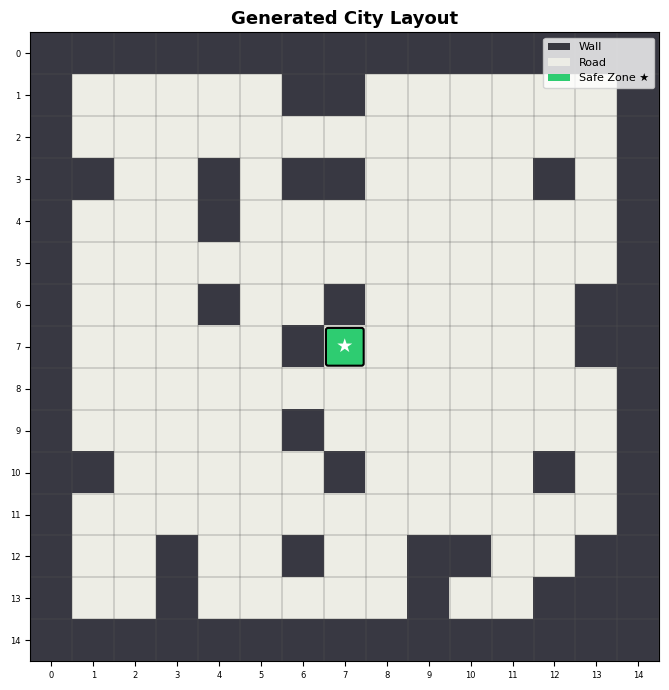

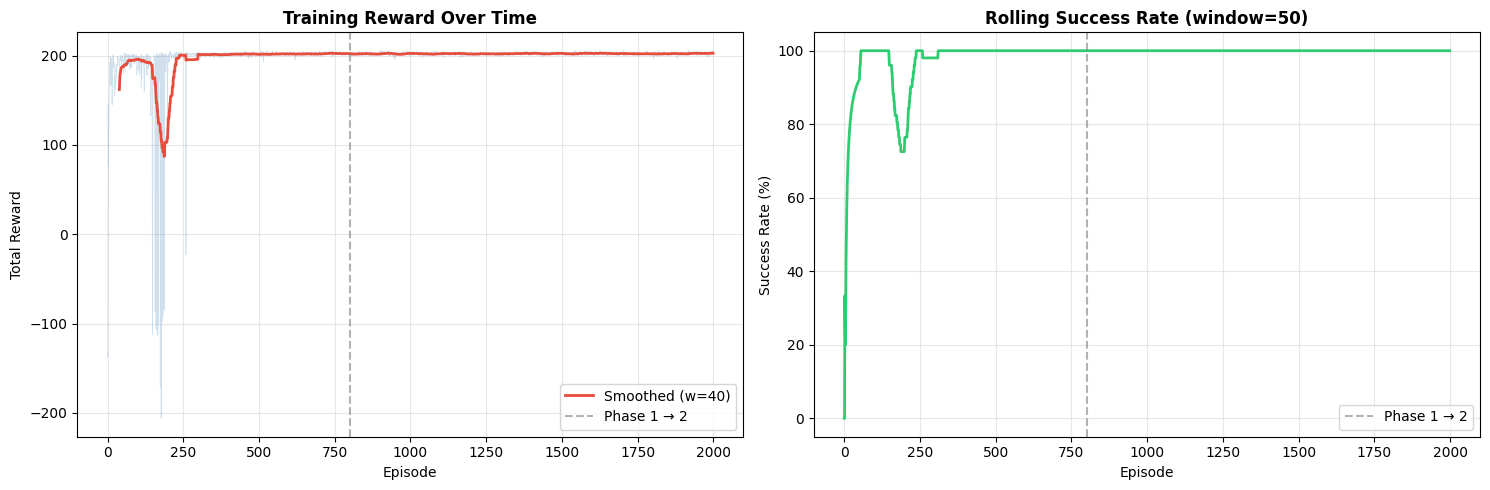

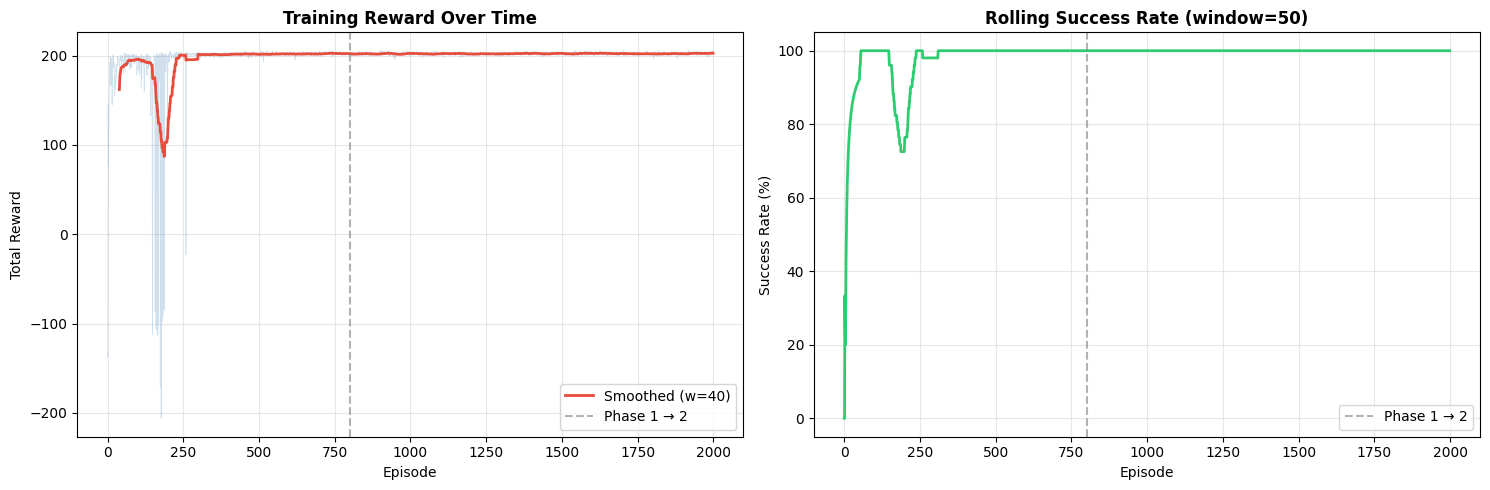

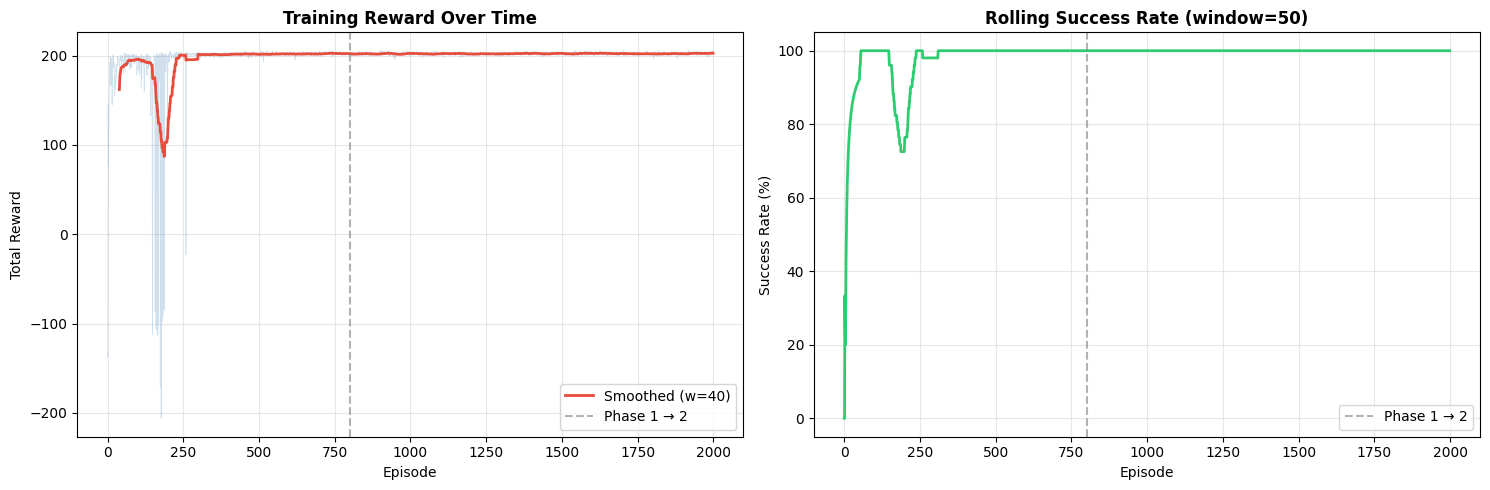

In [23]:
# ── Plot Training Curves ──────────────────────────────────────────
def smooth(data, window=30):
    if len(data) < window:
        return data
    cumsum = np.cumsum(np.insert(data, 0, 0))
    return (cumsum[window:] - cumsum[:-window]) / window

all_rewards = rewards_p1 + rewards_p2

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Left: full curve
ax = axes[0]
ax.plot(all_rewards, alpha=0.25, color='steelblue', linewidth=0.5)
sm = smooth(all_rewards, 40)
ax.plot(range(40-1, 40-1+len(sm)), sm, color='#e74c3c', linewidth=2, label='Smoothed (w=40)')
ax.axvline(PHASE1_EPISODES, color='grey', linestyle='--', alpha=0.6, label='Phase 1 → 2')
ax.set_xlabel('Episode')
ax.set_ylabel('Total Reward')
ax.set_title('Training Reward Over Time', fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

# Right: success rate (rolling window)
ax2 = axes[1]
window = 50
successes = [1 if r > 100 else 0 for r in all_rewards]  # rough success proxy
if len(successes) >= window:
    rates = [np.mean(successes[max(0,i-window):i+1]) * 100 for i in range(len(successes))]
    ax2.plot(rates, color='#2ecc71', linewidth=2)
ax2.axvline(PHASE1_EPISODES, color='grey', linestyle='--', alpha=0.6, label='Phase 1 → 2')
ax2.set_xlabel('Episode')
ax2.set_ylabel('Success Rate (%)')
ax2.set_title('Rolling Success Rate (window=50)', fontweight='bold')
ax2.set_ylim(-5, 105)
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 6 · Evaluation & Animated GIFs

In [13]:
# ── Evaluation Helper ─────────────────────────────────────────────
def evaluate_episode(agent, env, start_pos=None, max_steps=200):
    """Run one greedy episode; return path and total reward."""
    obs = env.reset(start_pos=start_pos)
    path = [env.thief_pos]
    total_r = 0.0
    while not env.done:
        action = agent.select_action(obs, evaluate=True)
        obs, r, done, info = env.step(action)
        path.append(env.thief_pos)
        total_r += r
    return path, total_r, env.thief_pos == env.safe_zone

In [14]:
# ── Generate Animated GIFs ────────────────────────────────────────
NUM_EVAL = 5
gif_paths = []

for i in range(NUM_EVAL):
    path, total_r, success = evaluate_episode(agent, env)
    status = '✓ ESCAPED' if success else '✗ CAUGHT'
    print(f'Eval {i+1}: start={path[0]}  steps={len(path)-1}  '
          f'reward={total_r:.1f}  {status}')

    # Build animation
    fig, ax = plt.subplots(figsize=(7, 7))

    def animate(frame, path=path, ax=ax):
        ax.clear()
        partial_path = path[:frame+1]
        plot_city(CITY_GRID, SAFE_ZONE, thief_pos=path[frame],
                 path=partial_path, ax=ax,
                 title=f'Eval {i+1}  —  Step {frame}/{len(path)-1}')
        # Legend
        legend_elements = [
            mpatches.Patch(facecolor='#e74c3c', label='Thief'),
            mpatches.Patch(facecolor='#2ecc71', label='Safe Zone'),
            mpatches.Patch(facecolor='#3498db', label='Path'),
        ]
        ax.legend(handles=legend_elements, loc='upper right', fontsize=7)

    # Create animation — sample frames if path is very long
    total_frames = len(path)
    if total_frames > 120:
        frame_indices = np.linspace(0, total_frames-1, 120, dtype=int).tolist()
    else:
        frame_indices = list(range(total_frames))

    def animate_sampled(frame_idx, frame_indices=frame_indices, path=path, ax=ax):
        real_frame = frame_indices[frame_idx]
        ax.clear()
        partial = path[:real_frame+1]
        plot_city(CITY_GRID, SAFE_ZONE, thief_pos=path[real_frame],
                 path=partial, ax=ax,
                 title=f'Eval {i+1}  —  Step {real_frame}/{len(path)-1}')
        legend_elements = [
            mpatches.Patch(facecolor='#e74c3c', label='Thief'),
            mpatches.Patch(facecolor='#2ecc71', label='Safe Zone'),
            mpatches.Patch(facecolor='#3498db', label='Path'),
        ]
        ax.legend(handles=legend_elements, loc='upper right', fontsize=7)

    anim = animation.FuncAnimation(fig, animate_sampled,
                                    frames=len(frame_indices),
                                    interval=120, repeat=False)
    gif_name = f'eval_{i+1}.gif'
    anim.save(gif_name, writer='pillow', fps=8)
    plt.close(fig)
    gif_paths.append(gif_name)
    print(f'  → Saved {gif_name}')

print(f'\nAll {NUM_EVAL} evaluation GIFs saved.')

Eval 1: start=(11, 9)  steps=6  reward=202.5  ✓ ESCAPED
  → Saved eval_1.gif
Eval 2: start=(5, 4)  steps=7  reward=201.2  ✓ ESCAPED
  → Saved eval_2.gif
Eval 3: start=(9, 11)  steps=6  reward=202.5  ✓ ESCAPED
  → Saved eval_3.gif
Eval 4: start=(11, 12)  steps=9  reward=204.0  ✓ ESCAPED
  → Saved eval_4.gif
Eval 5: start=(8, 2)  steps=6  reward=202.5  ✓ ESCAPED
  → Saved eval_5.gif

All 5 evaluation GIFs saved.



 eval_1.gif


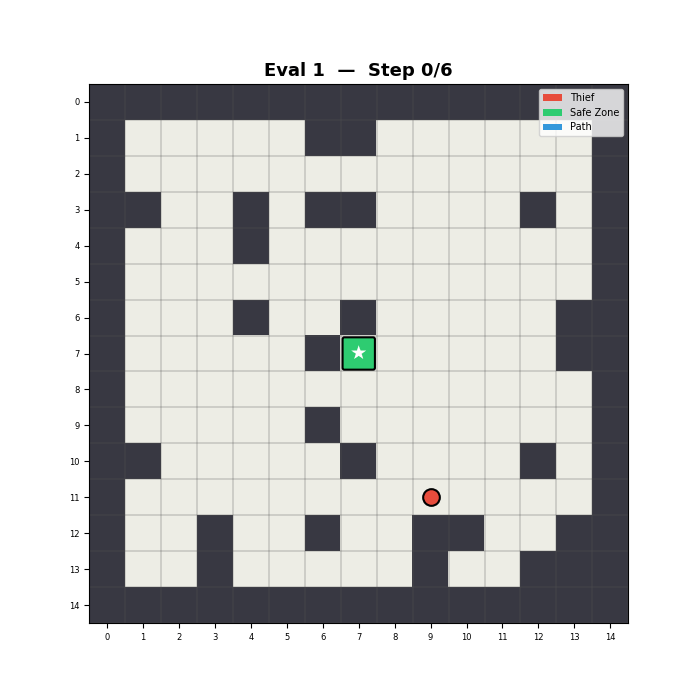


 eval_2.gif


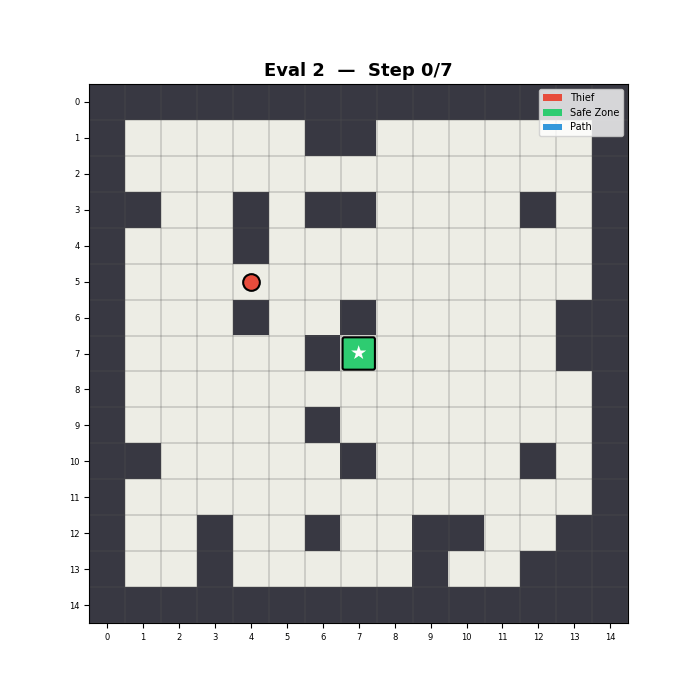


 eval_3.gif


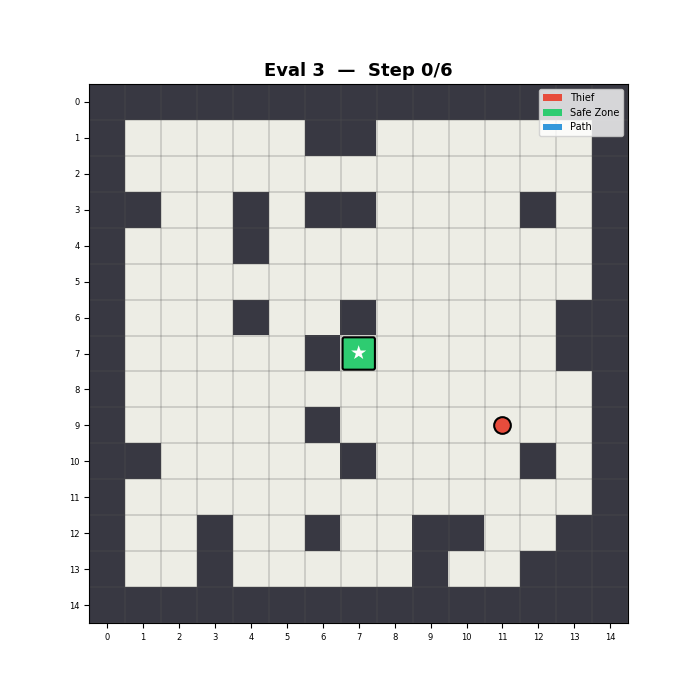


 eval_4.gif


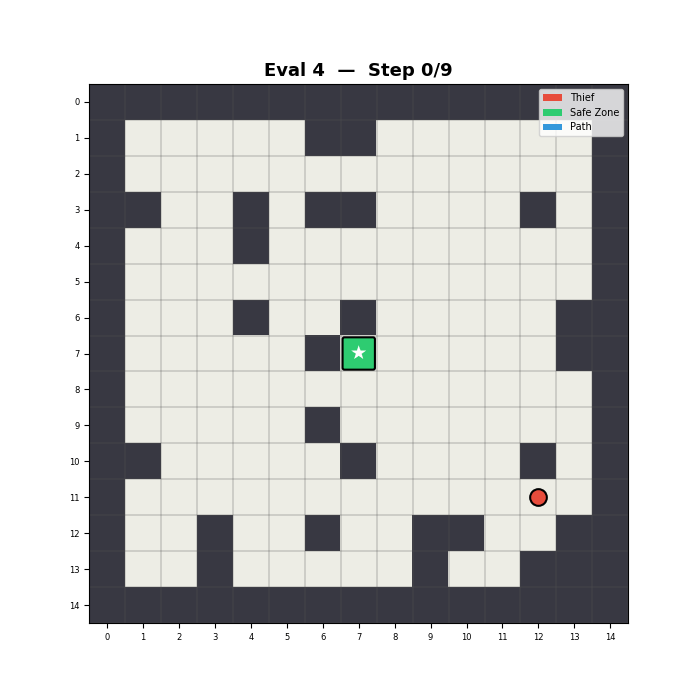


 eval_5.gif


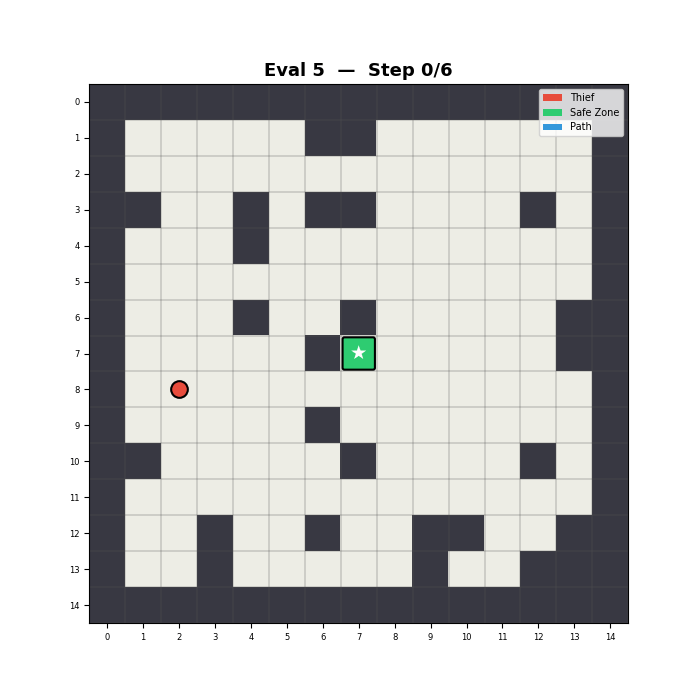

In [17]:
# ── Display GIFs ──────────────────────────────────────────────────
for gp in gif_paths:
    print(f'\n {gp}')
    display(Image(filename=gp))

In [16]:
# ── Final Stats ───────────────────────────────────────────────────
print('\n' + '═' * 60)
print('  BATCH EVALUATION  (100 random spawns)')
print('═' * 60)
wins, total_steps, total_r = 0, 0, 0.0
for _ in range(100):
    path, r, success = evaluate_episode(agent, env)
    wins += int(success)
    total_steps += len(path) - 1
    total_r += r

print(f'Success rate  : {wins}%')
print(f'Avg steps     : {total_steps / 100:.1f}')
print(f'Avg reward    : {total_r / 100:.1f}')
print('═' * 60)


════════════════════════════════════════════════════════════
  BATCH EVALUATION  (100 random spawns)
════════════════════════════════════════════════════════════
Success rate  : 100%
Avg steps     : 7.0
Avg reward    : 202.3
════════════════════════════════════════════════════════════
